# Diffusion-Based Stock Scenario Generator

Main parts:

1. Unconditional DDPM for multi-asset return windows.
2. Gaussian baseline.
3. Conditional DDPM for `calm / normal / stress` volatility regimes.
4. Financial evaluation: statistics, correlations, VaR, CVaR.
5. Simple Black-Scholes option-pricing layer.

The project was inspired by *Multi-Asset Spot and Option Market Simulation*

## 1. Setup

In [1]:
%pip install -q yfinance


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import sys

# Works when the notebook is run from the repository root or from notebooks/.
candidates = [Path.cwd(), Path.cwd().parent, Path.cwd() / 'Final Project', Path('/content/Final Project')]
PROJECT_ROOT = None
for candidate in candidates:
    if (candidate / 'src' / 'market_diffusion').exists():
        PROJECT_ROOT = candidate.resolve()
        break

if PROJECT_ROOT is None:
    raise RuntimeError('Could not find src/market_diffusion. Run this notebook from the repository root or clone/upload the full repo.')

sys.path.insert(0, str(PROJECT_ROOT / 'src'))
print('Project root:', PROJECT_ROOT)

Project root: /Users/fazhirkov/AIFT/Deep Learning/Final Project


In [3]:
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from IPython.display import display

from market_diffusion.config import ProjectConfig, get_device, seed_everything
from market_diffusion.data import (
    compute_log_returns,
    download_prices,
    standardize_returns,
    train_test_split_returns,
)
from market_diffusion.diffusion import (
    ConditionalDenoiseMLP,
    DenoiseMLP,
    DiffusionSchedule,
    sample_conditional_ddpm,
    sample_ddpm,
    train_conditional_ddpm,
    train_ddpm,
)
from market_diffusion.evaluation import (
    average_window_acf,
    corr_df,
    correlation_error,
    sample_gaussian_windows,
    scenario_var_cvar,
    stats_table,
    var_cvar_from_returns,
)
from market_diffusion.options import option_scenario_table, var_cvar_from_pnl_returns
from market_diffusion.plotting import (
    plot_conditional_regime_distributions,
    plot_correlation_heatmaps,
    plot_price_and_returns,
    plot_price_paths_by_source,
    plot_return_distribution,
    plot_training_loss,
)
from market_diffusion.windows import (
    REGIME_NAMES,
    assign_vol_regimes,
    build_regime_labels,
    flatten_windows,
    inverse_scale_windows,
    make_windows,
    regime_reference_table,
    window_portfolio_log_return,
    window_realized_volatility,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')

## 2. Configuration

In [4]:
cfg = ProjectConfig()
seed_everything(cfg.seed)
device = get_device()

EPOCHS = cfg.epochs_gpu if device.type == 'cuda' else cfg.epochs_cpu
CONDITIONAL_EPOCHS = cfg.conditional_epochs_gpu if device.type == 'cuda' else cfg.conditional_epochs_cpu

print('Device:', device)
print('Base DDPM epochs:', EPOCHS)
print('Conditional DDPM epochs:', CONDITIONAL_EPOCHS)
print(cfg)

Device: mps
Base DDPM epochs: 2000
Conditional DDPM epochs: 2000
ProjectConfig(tickers=('AAPL', 'MSFT', 'NVDA', 'JPM', 'XOM'), start_date='2014-01-01', end_date='2025-12-31', train_fraction=0.8, window_size=20, diffusion_steps=100, batch_size=256, epochs_gpu=2000, epochs_cpu=2000, conditional_epochs_gpu=2000, conditional_epochs_cpu=2000, learning_rate=0.0001, hidden_dim=256, time_emb_dim=64, regime_emb_dim=32, n_scenarios=3000, conditional_n_per_regime=1000, guidance_scale=1.5, conditional_label_drop_prob=0.15, clip_daily_return=0.35, portfolio_alpha=0.05, option_asset='AAPL', option_maturity_days=30, option_moneyness=1.0, risk_free_rate=0.04, synthetic_fallback_if_download_fails=True, seed=42)


## 3. Data and Rolling Windows

In [5]:
prices = download_prices(cfg)
returns = compute_log_returns(prices)
train_returns, test_returns = train_test_split_returns(returns, cfg.train_fraction)
train_scaled, test_scaled, train_mean, train_std = standardize_returns(train_returns, test_returns)

train_windows_scaled = make_windows(train_scaled, cfg.window_size)
test_windows_raw = make_windows(test_returns, cfg.window_size)
train_windows_raw = make_windows(train_returns, cfg.window_size)

n_assets = len(cfg.tickers)
input_dim = cfg.window_size * n_assets
asset_idx = list(cfg.tickers).index(cfg.option_asset)
s0 = float(prices[cfg.option_asset].iloc[-1])

print('Prices:', prices.shape)
print('Returns:', returns.shape)
print('Train windows:', train_windows_scaled.shape)
print('Test windows:', test_windows_raw.shape)
display(returns.describe().T[['mean', 'std', 'min', 'max']].round(5))

Prices: (3017, 5)
Returns: (3016, 5)
Train windows: (2393, 20, 5)
Test windows: (585, 20, 5)


,mean,std,min,max
Ticker,,,,
AAPL,0.00092,0.01782,-0.13771,0.14262
MSFT,0.00092,0.01656,-0.15945,0.13293
NVDA,0.00206,0.02952,-0.20771,0.26088
JPM,0.00067,0.01667,-0.16211,0.16562
XOM,0.00023,0.01682,-0.13039,0.11944


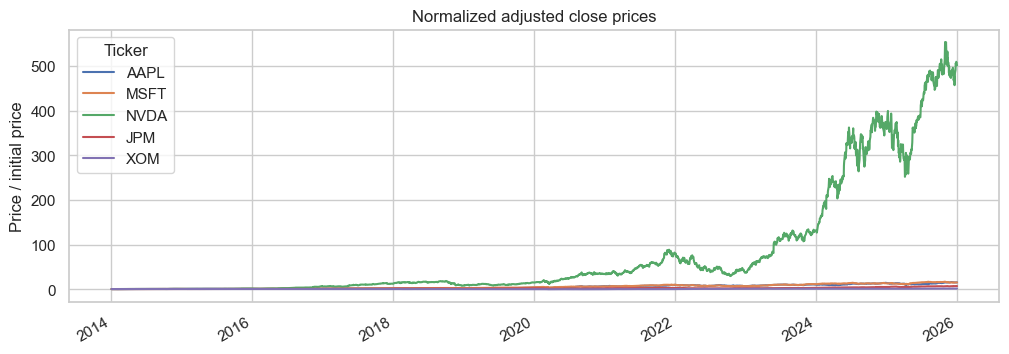

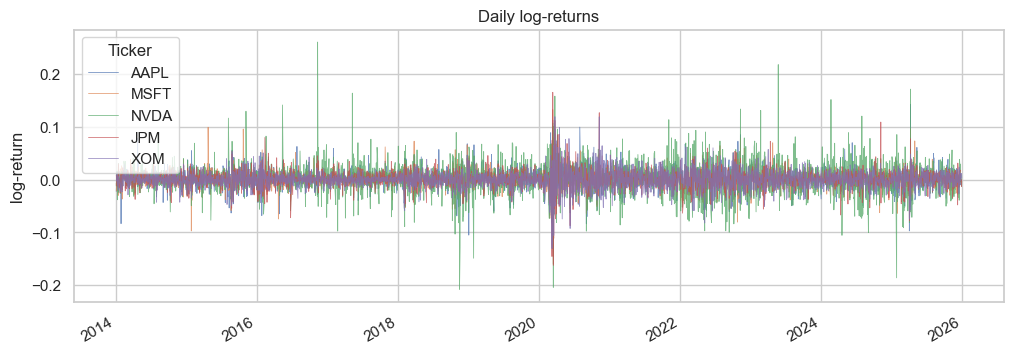

In [6]:
plot_price_and_returns(prices, returns)

## 4. Train Unconditional DDPM

The base model learns an unconditional distribution of 20-day multi-asset return windows:

$$
\epsilon_\theta(x_t, t)
$$

Epoch    1/2000 | loss=1.02503
Epoch  200/2000 | loss=0.65931
Epoch  400/2000 | loss=0.65567
Epoch  600/2000 | loss=0.64151
Epoch  800/2000 | loss=0.64206
Epoch 1000/2000 | loss=0.62648
Epoch 1200/2000 | loss=0.62875
Epoch 1400/2000 | loss=0.61947
Epoch 1600/2000 | loss=0.62048
Epoch 1800/2000 | loss=0.61664
Epoch 2000/2000 | loss=0.61296


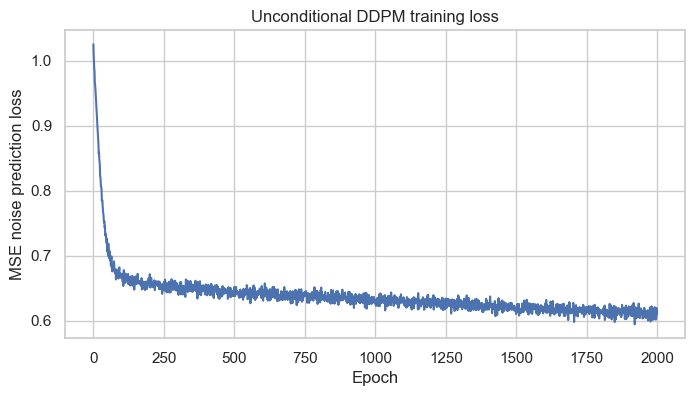

In [7]:
schedule = DiffusionSchedule(cfg.diffusion_steps, device)
base_model = DenoiseMLP(input_dim, cfg.hidden_dim, cfg.time_emb_dim).to(device)

base_history = train_ddpm(
    base_model,
    schedule,
    train_windows_scaled,
    batch_size=cfg.batch_size,
    learning_rate=cfg.learning_rate,
    device=device,
    epochs=EPOCHS,
)
plot_training_loss(base_history, 'Unconditional DDPM training loss')

## 5. Generate Scenarios and Gaussian Baseline

In [8]:
diffusion_windows_scaled = sample_ddpm(
    base_model,
    schedule,
    cfg.n_scenarios,
    input_dim,
    cfg.window_size,
    n_assets,
    device,
)
gaussian_windows_scaled = sample_gaussian_windows(train_windows_scaled, cfg.n_scenarios)

diffusion_windows = inverse_scale_windows(diffusion_windows_scaled, train_mean, train_std, cfg.clip_daily_return)
gaussian_windows = inverse_scale_windows(gaussian_windows_scaled, train_mean, train_std, cfg.clip_daily_return)
real_windows = np.clip(test_windows_raw, -cfg.clip_daily_return, cfg.clip_daily_return)

real_returns_flat = flatten_windows(real_windows)
diffusion_returns_flat = flatten_windows(diffusion_windows)
gaussian_returns_flat = flatten_windows(gaussian_windows)

print('Diffusion windows:', diffusion_windows.shape)
print('Gaussian windows:', gaussian_windows.shape)

Diffusion windows: (3000, 20, 5)
Gaussian windows: (3000, 20, 5)


## 6. Distribution, Correlation, and Risk Evaluation

,dataset,asset,mean,std,skew,excess_kurtosis,q01,q05,q95,q99
0,Real test,AAPL,0.00076,0.01684,0.55363,11.55776,-0.04332,-0.02659,0.02181,0.04236
1,Real test,MSFT,0.00072,0.01378,0.23695,6.26467,-0.03651,-0.02280,0.02069,0.03144
2,Real test,NVDA,0.00239,0.03086,-0.12538,4.90790,-0.08128,-0.04451,0.04377,0.07835
3,Real test,JPM,0.00136,0.01445,-0.17102,10.02794,-0.04561,-0.01915,0.01953,0.03169
4,Real test,XOM,0.00028,0.01368,-0.49704,2.12835,-0.03651,-0.02139,0.02121,0.03143
5,Diffusion,AAPL,0.00127,0.01518,-0.01926,0.25583,-0.03515,-0.02374,0.02598,0.03720
6,Diffusion,MSFT,0.00115,0.01418,0.01663,0.25688,-0.03250,-0.02215,0.02448,0.03495
7,Diffusion,NVDA,0.00232,0.02516,0.10836,0.29177,-0.05619,-0.03851,0.04407,0.06384
8,Diffusion,JPM,0.00086,0.01383,0.01220,0.24197,-0.03169,-0.02180,0.02356,0.03370
9,Diffusion,XOM,0.00046,0.01461,0.01792,0.26656,-0.03412,-0.02351,0.02452,0.03551


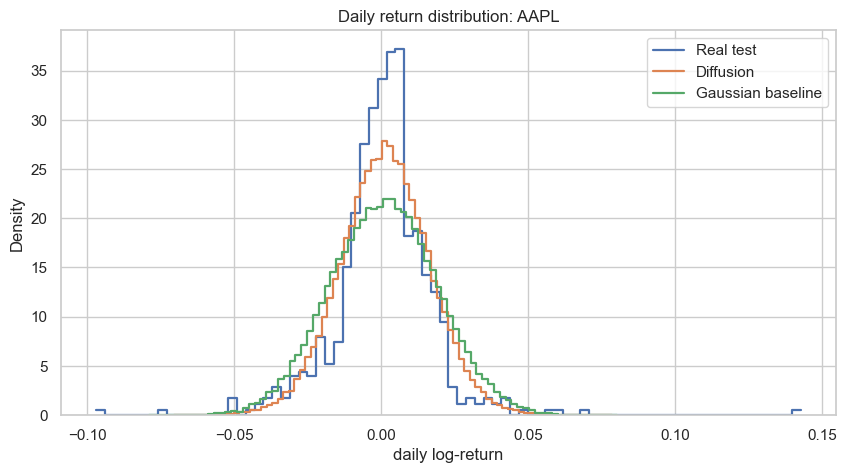

In [9]:
stats = pd.concat([
    stats_table(real_returns_flat, 'Real test', cfg.tickers),
    stats_table(diffusion_returns_flat, 'Diffusion', cfg.tickers),
    stats_table(gaussian_returns_flat, 'Gaussian baseline', cfg.tickers),
], ignore_index=True)
display(stats.round(5))

plot_return_distribution(
    {
        'Real test': real_returns_flat,
        'Diffusion': diffusion_returns_flat,
        'Gaussian baseline': gaussian_returns_flat,
    },
    asset_idx,
    cfg.option_asset,
)

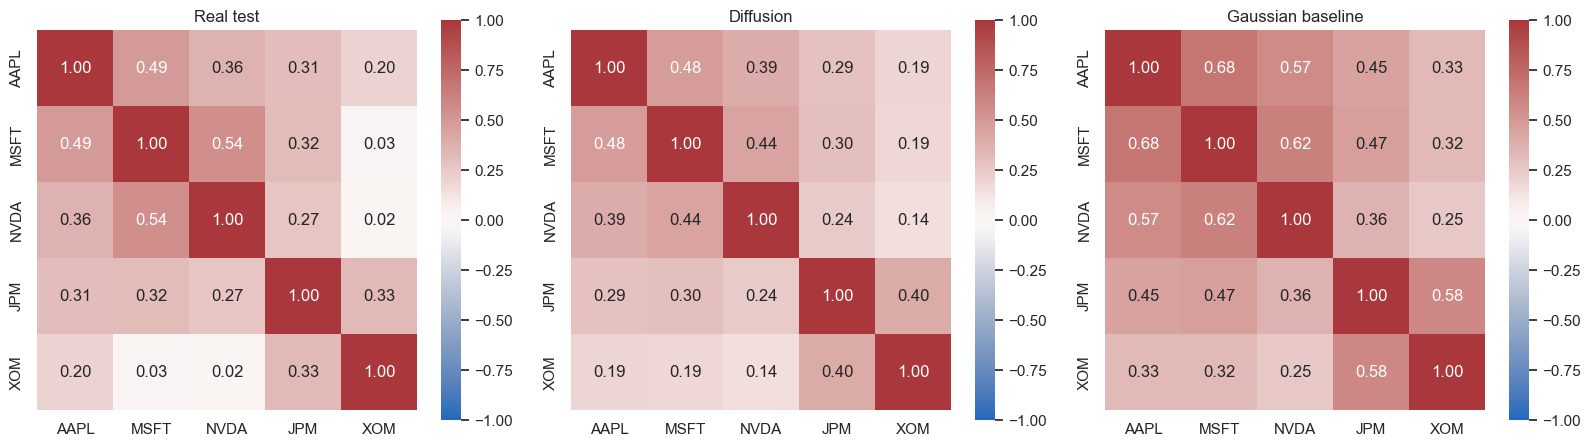

,model,frobenius_corr_error
0,Diffusion,0.3380
1,Gaussian baseline,0.8457


In [10]:
real_corr = corr_df(real_returns_flat, cfg.tickers)
diff_corr = corr_df(diffusion_returns_flat, cfg.tickers)
gauss_corr = corr_df(gaussian_returns_flat, cfg.tickers)

plot_correlation_heatmaps({
    'Real test': real_corr,
    'Diffusion': diff_corr,
    'Gaussian baseline': gauss_corr,
})

display(pd.DataFrame({
    'model': ['Diffusion', 'Gaussian baseline'],
    'frobenius_corr_error': [
        correlation_error(real_corr, diff_corr),
        correlation_error(real_corr, gauss_corr),
    ],
}).round(4))

In [11]:
risk_rows = []
for name, arr in [
    ('Real test', real_returns_flat),
    ('Diffusion', diffusion_returns_flat),
    ('Gaussian baseline', gaussian_returns_flat),
]:
    var, cvar = var_cvar_from_returns(arr, cfg.portfolio_alpha)
    risk_rows.append({
        'dataset': name,
        f'VaR_{int((1-cfg.portfolio_alpha)*100)}_loss': var,
        f'CVaR_{int((1-cfg.portfolio_alpha)*100)}_loss': cvar,
    })
display(pd.DataFrame(risk_rows).round(5))

,dataset,VaR_95_loss,CVaR_95_loss
0,Real test,0.01700,0.02757
1,Diffusion,0.01745,0.02254
2,Gaussian baseline,0.02379,0.03010


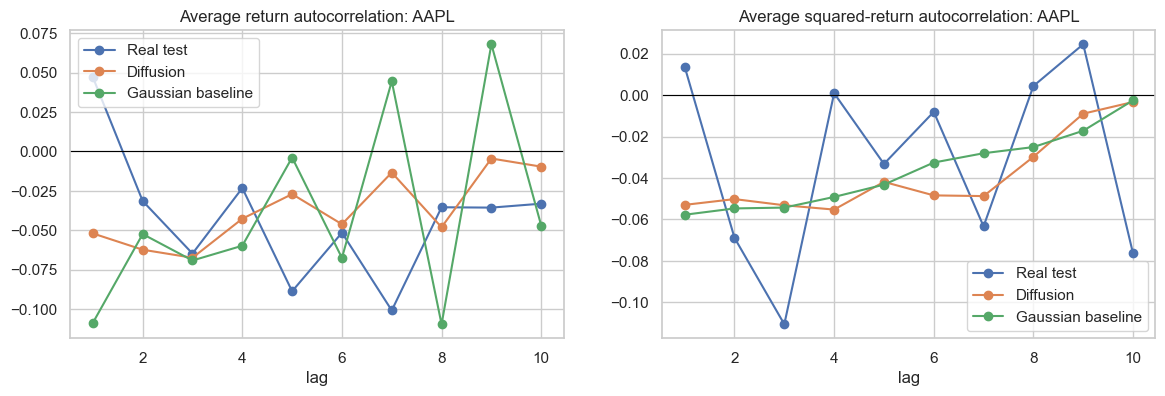

In [12]:
max_lag = 10
lags = np.arange(1, max_lag + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for source_name, source_windows in [('Real test', real_windows), ('Diffusion', diffusion_windows), ('Gaussian baseline', gaussian_windows)]:
    axes[0].plot(lags, average_window_acf(source_windows, asset_idx, max_lag, squared=False), marker='o', label=source_name)
    axes[1].plot(lags, average_window_acf(source_windows, asset_idx, max_lag, squared=True), marker='o', label=source_name)
axes[0].set_title(f'Average return autocorrelation: {cfg.option_asset}')
axes[1].set_title(f'Average squared-return autocorrelation: {cfg.option_asset}')
for ax in axes:
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xlabel('lag')
    ax.legend()
plt.show()

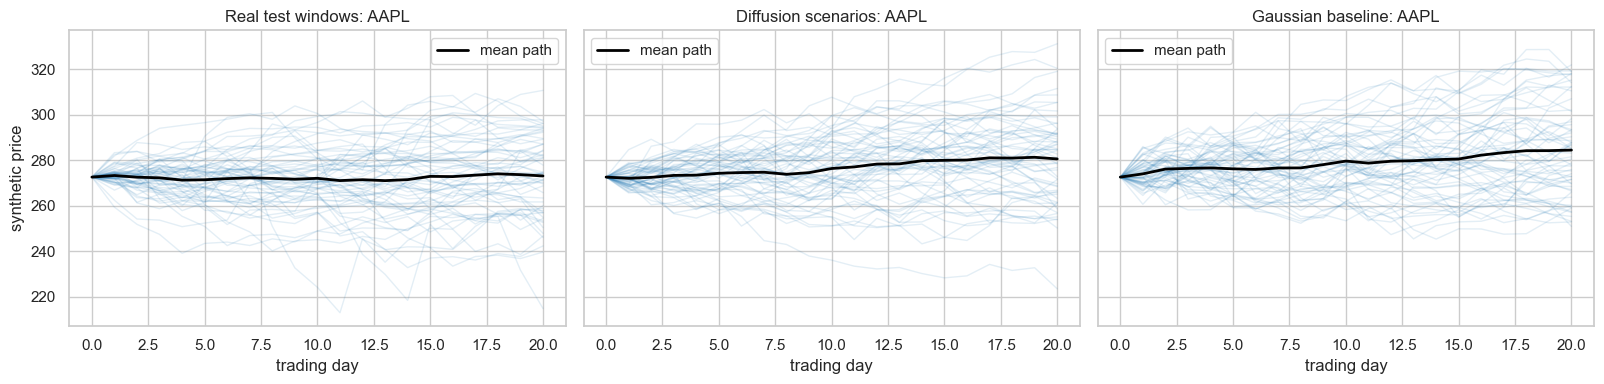

In [13]:
plot_price_paths_by_source(
    {
        'Real test windows': real_windows,
        'Diffusion scenarios': diffusion_windows,
        'Gaussian baseline': gaussian_windows,
    },
    asset_idx,
    cfg.option_asset,
    s0,
)

## 7. Conditional DDPM for Volatility Regimes

We label historical windows by realized volatility and train a conditional diffusion model:

$$
\epsilon_\theta(x_t, t, y), \quad y \in \{\text{calm}, \text{normal}, \text{stress}\}
$$

This lets us request a regime during sampling instead of generating only unconditional scenarios.

,regime,train_window_count,volatility_rule
0,calm,798,vol <= 0.142
1,normal,797,0.142 < vol <= 0.228
2,stress,798,vol > 0.228


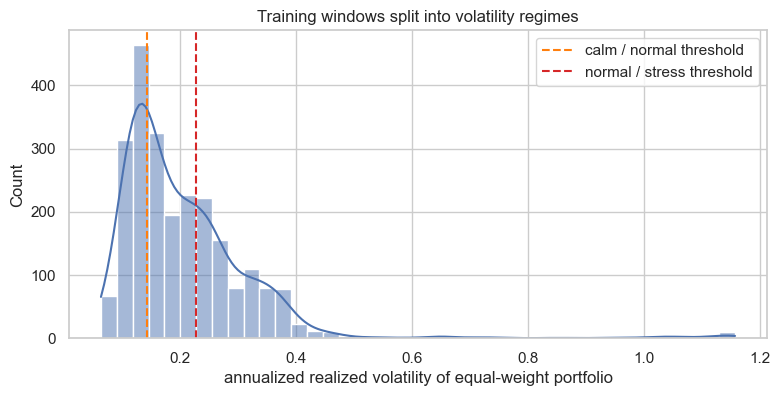

In [14]:
regime_labels, thresholds, train_window_vol = build_regime_labels(train_windows_raw)
unknown_regime_label = len(REGIME_NAMES)

display(regime_reference_table(regime_labels, thresholds))

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(train_window_vol, bins=40, kde=True, ax=ax)
ax.axvline(thresholds[0], color='tab:orange', linestyle='--', label='calm / normal threshold')
ax.axvline(thresholds[1], color='tab:red', linestyle='--', label='normal / stress threshold')
ax.set_title('Training windows split into volatility regimes')
ax.set_xlabel('annualized realized volatility of equal-weight portfolio')
ax.legend()
plt.show()

Conditional epoch    1/2000 | loss=1.02046
Conditional epoch  200/2000 | loss=0.64653
Conditional epoch  400/2000 | loss=0.64963
Conditional epoch  600/2000 | loss=0.64494
Conditional epoch  800/2000 | loss=0.63249
Conditional epoch 1000/2000 | loss=0.63205
Conditional epoch 1200/2000 | loss=0.61886
Conditional epoch 1400/2000 | loss=0.62354
Conditional epoch 1600/2000 | loss=0.61937
Conditional epoch 1800/2000 | loss=0.61648
Conditional epoch 2000/2000 | loss=0.60768


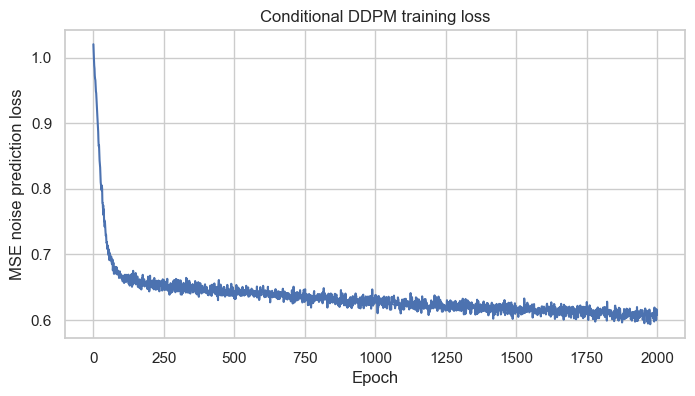

In [15]:
conditional_model = ConditionalDenoiseMLP(
    input_dim=input_dim,
    hidden_dim=cfg.hidden_dim,
    time_emb_dim=cfg.time_emb_dim,
    n_regimes=len(REGIME_NAMES),
    regime_emb_dim=cfg.regime_emb_dim,
).to(device)

conditional_history = train_conditional_ddpm(
    conditional_model,
    schedule,
    train_windows_scaled,
    regime_labels,
    batch_size=cfg.batch_size,
    learning_rate=cfg.learning_rate,
    device=device,
    epochs=CONDITIONAL_EPOCHS,
    unknown_regime_label=unknown_regime_label,
    label_drop_prob=cfg.conditional_label_drop_prob,
)
plot_training_loss(conditional_history, 'Conditional DDPM training loss')

In [16]:
conditional_n = min(cfg.conditional_n_per_regime, cfg.n_scenarios)
conditional_windows_by_regime = {}
for regime_id, regime_name in REGIME_NAMES.items():
    scaled = sample_conditional_ddpm(
        conditional_model,
        schedule,
        conditional_n,
        input_dim,
        cfg.window_size,
        n_assets,
        device,
        regime_label=regime_id,
        unknown_regime_label=unknown_regime_label,
        guidance_scale=cfg.guidance_scale,
    )
    conditional_windows_by_regime[regime_name] = inverse_scale_windows(
        scaled,
        train_mean,
        train_std,
        cfg.clip_daily_return,
    )

conditional_rows = []
for regime_name, windows in conditional_windows_by_regime.items():
    vol = window_realized_volatility(windows)
    horizon_log_returns = window_portfolio_log_return(windows)
    var, cvar = scenario_var_cvar(horizon_log_returns, cfg.portfolio_alpha)
    generated_labels = assign_vol_regimes(vol, thresholds[0], thresholds[1])
    conditional_rows.append({
        'requested_regime': regime_name,
        'mean_realized_vol': vol.mean(),
        'median_realized_vol': np.median(vol),
        'mean_20d_portfolio_log_return': horizon_log_returns.mean(),
        f'20d_VaR_{int((1-cfg.portfolio_alpha)*100)}_loss': var,
        f'20d_CVaR_{int((1-cfg.portfolio_alpha)*100)}_loss': cvar,
        'share_classified_calm': np.mean(generated_labels == 0),
        'share_classified_normal': np.mean(generated_labels == 1),
        'share_classified_stress': np.mean(generated_labels == 2),
    })
display(pd.DataFrame(conditional_rows).round(4))

,requested_regime,mean_realized_vol,median_realized_vol,mean_20d_portfolio_log_return,20d_VaR_95_loss,20d_CVaR_95_loss,share_classified_calm,share_classified_normal,share_classified_stress
0,calm,0.1140,0.1123,0.0295,0.0213,0.0350,0.862,0.138,0.000
1,normal,0.1657,0.1656,0.0293,0.0449,0.0683,0.229,0.736,0.035
2,stress,0.2370,0.2356,0.0123,0.0838,0.1159,0.002,0.423,0.575


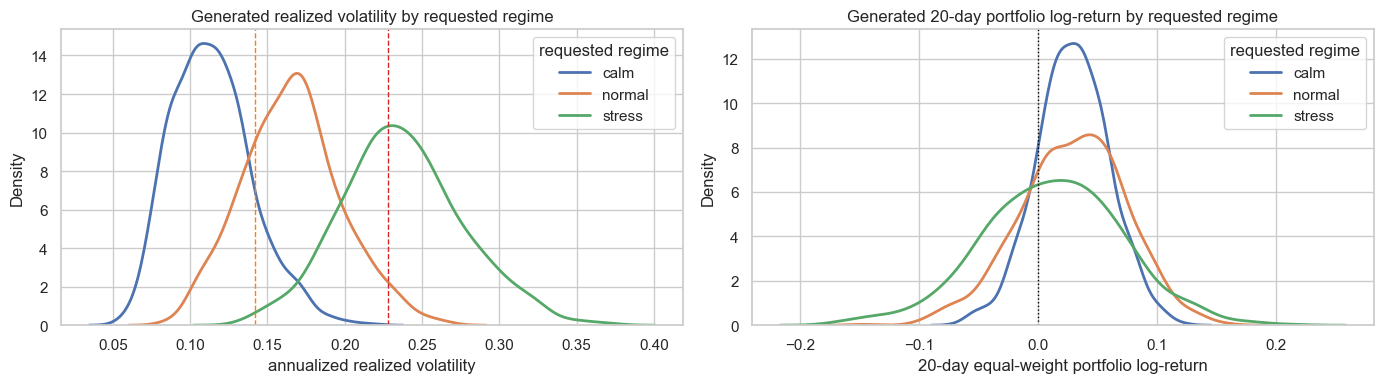

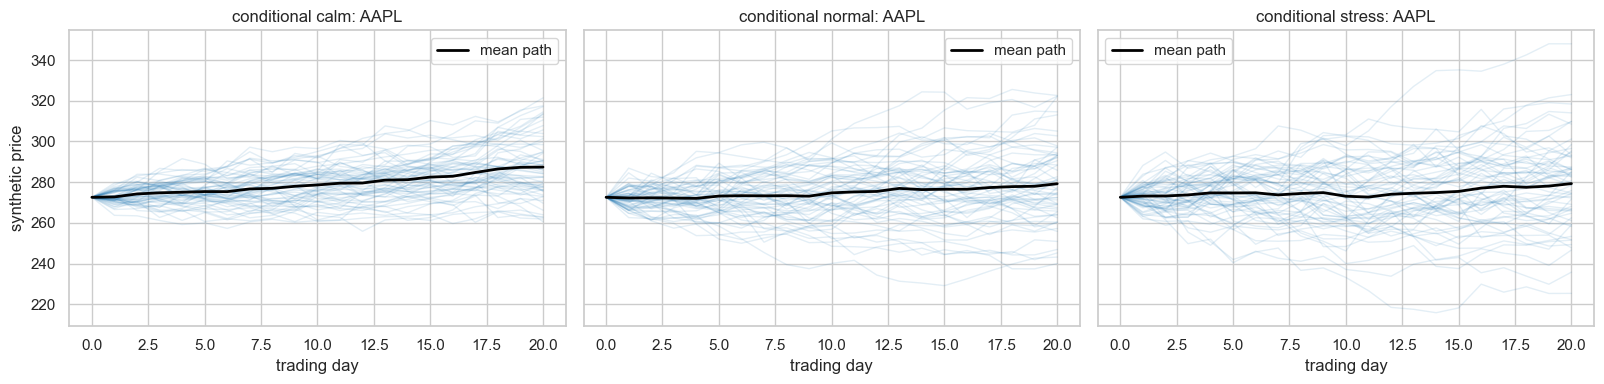

In [17]:
plot_conditional_regime_distributions(
    conditional_windows_by_regime,
    window_realized_volatility,
    window_portfolio_log_return,
    thresholds,
)
plot_price_paths_by_source(
    {f'conditional {k}': v for k, v in conditional_windows_by_regime.items()},
    asset_idx,
    cfg.option_asset,
    s0,
)

## 8. Simple Black-Scholes Option Layer

In [18]:
option_tables = pd.concat([
    option_scenario_table(
        real_windows,
        'Real test',
        cfg.option_asset,
        asset_idx,
        prices,
        train_returns,
        cfg.option_maturity_days,
        cfg.window_size,
        cfg.option_moneyness,
        cfg.risk_free_rate,
    ),
    option_scenario_table(
        diffusion_windows,
        'Diffusion',
        cfg.option_asset,
        asset_idx,
        prices,
        train_returns,
        cfg.option_maturity_days,
        cfg.window_size,
        cfg.option_moneyness,
        cfg.risk_free_rate,
    ),
    option_scenario_table(
        gaussian_windows,
        'Gaussian baseline',
        cfg.option_asset,
        asset_idx,
        prices,
        train_returns,
        cfg.option_maturity_days,
        cfg.window_size,
        cfg.option_moneyness,
        cfg.risk_free_rate,
    ),
], ignore_index=True)

display(option_tables.groupby('dataset')[['realized_vol', 'call_price_end', 'delta_end', 'stock_plus_call_return']].describe().round(4))

realized_vol                                          \
                         count    mean     std     min     25%     50%   
dataset                                                                  
Diffusion               3000.0  0.2360  0.0508  0.1051  0.2017  0.2319   
Gaussian baseline       3000.0  0.2853  0.0472  0.1459  0.2530  0.2837   
Real test                585.0  0.2423  0.1172  0.0941  0.1725  0.2278   

                                  call_price_end           ... delta_end       \
                      75%     max          count     mean  ...       75%  max   
dataset                                                    ...                  
Diffusion          0.2667  0.4600         3000.0  13.5402  ...    0.9478  1.0   
Gaussian baseline  0.3167  0.4930         3000.0  13.7829  ...    0.9001  1.0   
Real test          0.2707  0.8034          585.0  11.6801  ...    0.9224  1.0   

                  stock_plus_call_return                                  \
                                   count    mean     std     min     25%   
dataset                                                                    
Diffusion                         3000.0  0.0344  0.1078 -0.2494 -0.0481   
Gaussian baseline                 3000.0  0.0288  0.1216 -0.2658 -0.0615   
Real test                          585.0  0.0177  0.0996 -0.2503 -0.0556   

                                           
                      50%     75%     max  
dataset                                    
Diffusion          0.0228  0.1016  0.4920  
Gaussian baseline  0.0099  0.1003  0.5378  
Real test          0.0032  0.0846  0.3578  

[3 rows x 32 columns]

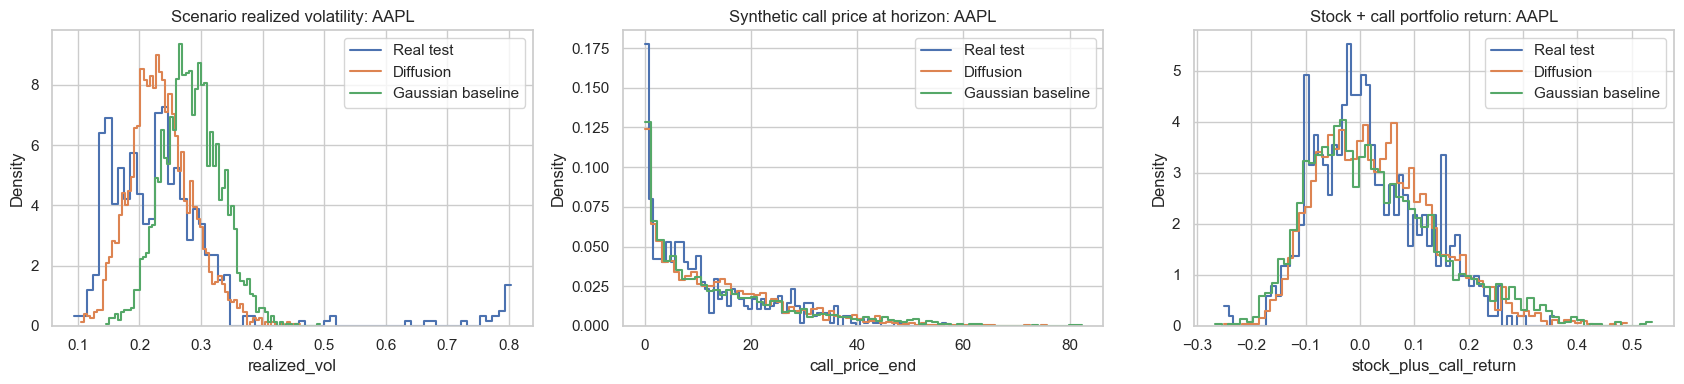

,dataset,stock_plus_call_VaR_95_loss,stock_plus_call_CVaR_95_loss
0,Diffusion,0.11684,0.14033
1,Gaussian baseline,0.13436,0.16138
2,Real test,0.12617,0.15270


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, column, title in zip(
    axes,
    ['realized_vol', 'call_price_end', 'stock_plus_call_return'],
    ['Scenario realized volatility', 'Synthetic call price at horizon', 'Stock + call portfolio return'],
):
    for name in ['Real test', 'Diffusion', 'Gaussian baseline']:
        values = option_tables.loc[option_tables['dataset'] == name, column]
        sns.histplot(values, bins=70, stat='density', element='step', fill=False, linewidth=1.5, label=name, ax=ax)
    ax.set_title(f'{title}: {cfg.option_asset}')
    ax.legend()
plt.tight_layout()
plt.show()

option_risk = []
for name, group in option_tables.groupby('dataset'):
    var, cvar = var_cvar_from_pnl_returns(group['stock_plus_call_return'], cfg.portfolio_alpha)
    option_risk.append({
        'dataset': name,
        f'stock_plus_call_VaR_{int((1-cfg.portfolio_alpha)*100)}_loss': var,
        f'stock_plus_call_CVaR_{int((1-cfg.portfolio_alpha)*100)}_loss': cvar,
    })
display(pd.DataFrame(option_risk).round(5))

## 9. Summary


1. **The DDPM learns a non-trivial distribution of multi-asset returns.**  
   The unconditional diffusion training loss decreased from about `1.03` to `0.61`, so the model learned to denoise return windows rather than outputting pure noise.

2. **The diffusion model preserves cross-asset dependence better than the Gaussian baseline.**  
   The Frobenius correlation error was approximately `0.338` for the diffusion model versus `0.846` for the Gaussian baseline. This is one of the strongest results in the notebook: even a compact MLP-based DDPM captures the joint stock structure better than a simple covariance baseline.

3. **The diffusion model produces realistic volatility scale, but still underestimates extreme tails.**  
   For daily return standard deviations, diffusion samples are close to real test data for most assets. However, real returns have very high excess kurtosis, especially for AAPL and JPM, while diffusion-generated returns have much lower kurtosis. This means the model captures the typical distribution shape better than rare crisis-like jumps.

4. **Risk metrics are plausible and less over-conservative than the Gaussian baseline.**  
   Equal-weight portfolio `VaR_95` was close for real data and diffusion samples: about `0.0170` for real test data and `0.0175` for diffusion. The Gaussian baseline produced a larger `VaR_95` around `0.0238`. For `CVaR_95`, diffusion was lower than real data, which again suggests that the model does not fully reproduce the most severe tail losses.

5. **The conditional DDPM is the most clearly deep-learning contribution.**  
   The conditional model learns controllable scenario generation. Requested `calm`, `normal`, and `stress` samples have clearly increasing realized volatility: about `0.114`, `0.166`, and `0.237`, respectively. The generated `20d_CVaR_95` also increases strongly from about `0.035` in the calm regime to `0.116` in the stress regime.

6. **Classifier-free guidance makes the regime conditioning visible.**  
   When requesting calm scenarios, about `86%` of generated samples are classified as calm. When requesting stress scenarios, about `58%` are classified as stress and most remaining samples fall into normal, not calm. This shows that the model is not perfectly regime-separated, but the conditioning is meaningful.

7. **The Black-Scholes layer connects generated stock scenarios to derivative risk.**  
   The synthetic stock-plus-call portfolio risk is in a realistic range. Diffusion gives `VaR_95` around `0.117` and `CVaR_95` around `0.140`, compared with real test values around `0.126` and `0.153`. The Gaussian baseline is more conservative at about `0.134` and `0.161`.